In [1]:
%pip install https://github.com/FraMedda/fmfinance/archive/refs/heads/main.zip

import numpy as np 
import pandas as pd 

import fmfinance as fm

import statsmodels.stats.api as sms
import statsmodels.api as sm
from statsmodels.compat import lzip
from statsmodels.regression.rolling import RollingOLS 
from statsmodels.datasets import longley
import quantstats as qs


import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm 
from scipy import stats

from datetime import datetime

from pandas.plotting import register_matplotlib_converters

import yfinance as yf

  Using cached main.zip (7.2 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [2]:
start = '2016-01-01'
end = '2026-04-30'

In [3]:
ff_3f = fm.ff('F-F_Research_Data_Factors_daily', start=start, end=end)
ff_3f = ff_3f[0]

ticker = ['NVDA']
stock = yf.download(ticker, start, end, auto_adjust=False, multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


In [4]:
stock = pd.DataFrame(stock['Adj Close'])
s_returns = stock.pct_change() * 100

In [5]:
df = pd.DataFrame()
df['Mkt-Rf'] = ff_3f['Mkt-RF']

df['Rendimenti'] = s_returns
df = df.dropna()

# Excess returns = rendimento titolo - tasso risk free
df['ER'] = df['Rendimenti'] - ff_3f['RF']
df = df.drop(['Rendimenti'], axis=1)

In [6]:
# Momenti della distribuzione
print(df['ER'].describe())
print(f"Skewness: {round(df['ER'].skew(), 3)}")
print(f"Kurtosis: {round(df['ER'].kurt(), 3)}")

count    2552.000000
mean        0.252134
std         3.132523
min       -18.765911
25%        -1.314406
50%         0.264146
75%         1.846075
max        29.806702
Name: ER, dtype: float64
Skewness: 0.517
Kurtosis: 7.966


In [7]:
# Indici di performance con quantstats
rets = df['ER'] / 100  # quantstats vuole i rendimenti in decimale, non in percentuale

cagr    = qs.stats.cagr(rets)
vol     = qs.stats.volatility(rets)
skew    = qs.stats.skew(rets)
kurt    = qs.stats.kurtosis(rets)
sharpe  = qs.stats.sharpe(rets)
sortino = qs.stats.sortino(rets)
max_dd  = qs.stats.max_drawdown(rets)
var_5   = qs.stats.value_at_risk(rets, sigma=0.05)
var_1   = qs.stats.value_at_risk(rets, sigma=0.01)

print(f"--- MOMENTI ---")
print(f"Expected Return (Ann.): {round(cagr * 100, 3)}%")
print(f"Volatility (Ann.):      {round(vol * 100, 3)}%")
print(f"Skewness:               {round(float(skew), 3)}")
print(f"Kurtosis:               {round(float(kurt), 3)}")

print(f"\n--- PERFORMANCE ---")
print(f"Sharpe Ratio:           {round(float(sharpe), 3)}")
print(f"Sortino Ratio:          {round(float(sortino), 3)}")

print(f"\n--- RISCHIO ---")
print(f"Max Drawdown:           {round(max_dd * 100, 3)}%")
print(f"VaR 5% (Daily):         {round(var_5 * 100, 3)}%")
print(f"VaR 1% (Daily):         {round(var_1 * 100, 3)}%")

--- MOMENTI ---
Expected Return (Ann.): 66.916%
Volatility (Ann.):      49.727%
Skewness:               0.517
Kurtosis:               7.966

--- PERFORMANCE ---
Sharpe Ratio:           1.278
Sortino Ratio:          1.963

--- RISCHIO ---
Max Drawdown:           -66.518%
VaR 5% (Daily):         -0.005%
VaR 1% (Daily):         0.201%


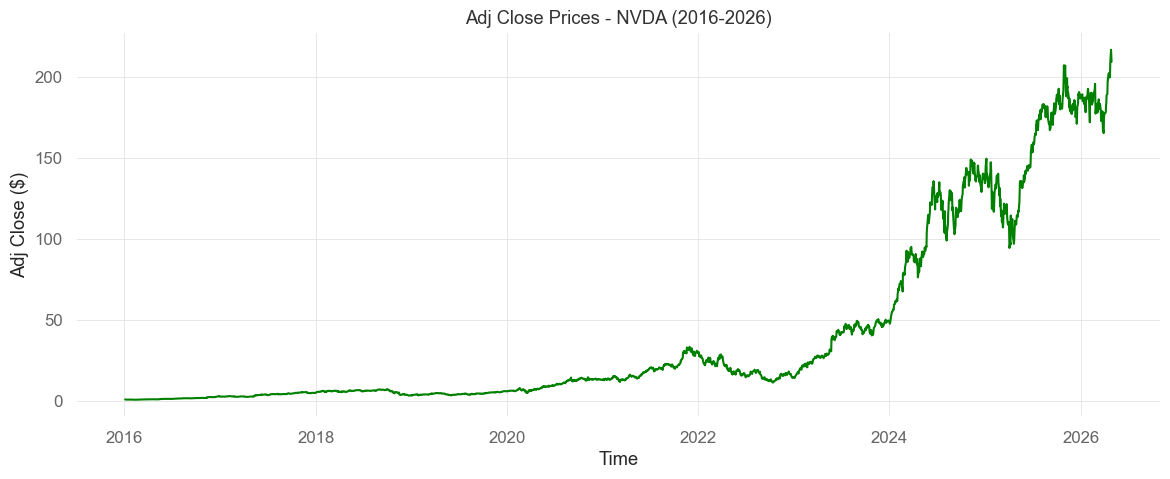

In [8]:
# 1. Andamento prezzi NVIDIA
plt.figure(figsize=(14, 5))
plt.title('Adj Close Prices - NVDA (2016-2026)')
plt.xlabel('Time')
plt.ylabel('Adj Close ($)')
plt.grid(True)
plt.plot(stock['Adj Close'], color='green', linewidth=1.5)
plt.show()

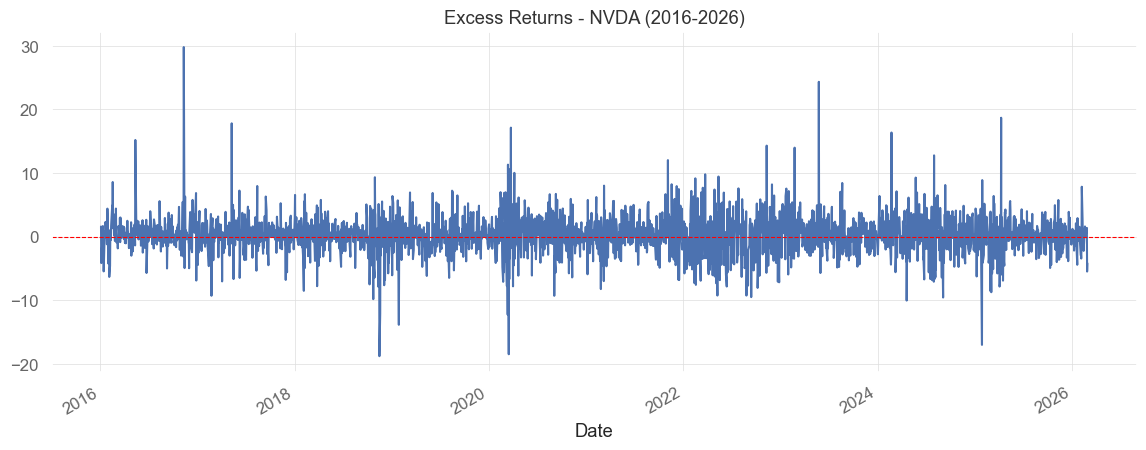

In [9]:
# 2. Serie storica degli Excess Returns
df['ER'].plot(title='Excess Returns - NVDA (2016-2026)', figsize=(14, 5))
plt.axhline(0, color='red', linewidth=0.8, linestyle='--')  # linea dello zero come riferimento
plt.show()

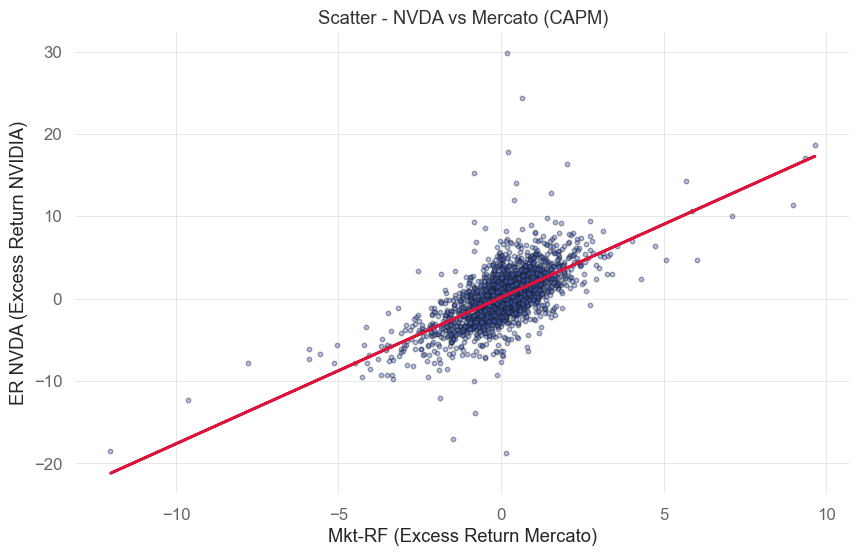

In [10]:
# Scatter plot corretto con excess returns su entrambi gli assi
Ret = pd.DataFrame()
Ret['Mkt-Rf'] = df['Mkt-Rf']
Ret['ER_NVDA'] = df['ER']
Ret = Ret.dropna()

plt.figure(figsize=(10, 6))
plt.scatter(Ret['Mkt-Rf'], Ret['ER_NVDA'], color='royalblue', edgecolors='k', alpha=0.4, s=10)

m, b = np.polyfit(Ret['Mkt-Rf'], Ret['ER_NVDA'], 1)
plt.plot(Ret['Mkt-Rf'], m * Ret['Mkt-Rf'] + b, color='crimson', linewidth=2)

plt.xlabel('Mkt-RF (Excess Return Mercato)')
plt.ylabel('ER NVDA (Excess Return NVIDIA)')
plt.title('Scatter - NVDA vs Mercato (CAPM)')
plt.grid(True)
plt.show()

In [11]:
# Regressione OLS - CAPM formale
# ER_NVDA = Alpha + Beta * Mkt-RF

x1 = df['Mkt-Rf']       # variabile indipendente
y  = df['ER']            # variabile dipendente

x  = sm.add_constant(x1) # aggiunge la costante per stimare Alpha

modello = sm.OLS(y, x).fit()
y.name  = 'ER_NVDA'

# modello.summary() #questa è la versione più semplice
print(modello.summary())

                            OLS Regression Results                            
Dep. Variable:                ER_NVDA   R-squared:                       0.439
Model:                            OLS   Adj. R-squared:                  0.439
Method:                 Least Squares   F-statistic:                     1998.
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        07:41:37   Log-Likelihood:                -5796.2
No. Observations:                2552   AIC:                         1.160e+04
Df Residuals:                    2550   BIC:                         1.161e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1579      0.046      3.397      0.0

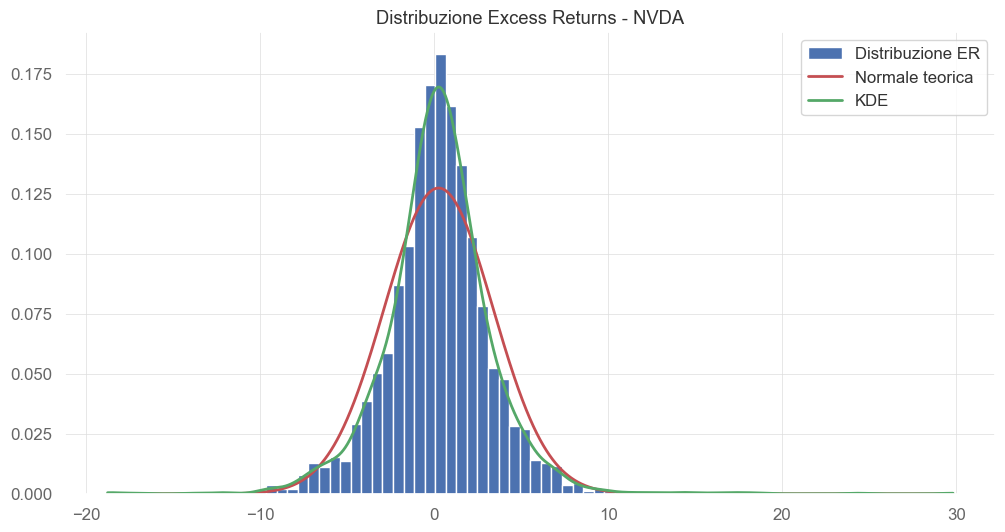

In [12]:
# 4. Istogramma con normale e KDE
plt.figure(figsize=(12, 6))
x_axis = np.arange(min(df['ER']), max(df['ER']), 0.001)
y      = norm.pdf(x_axis, np.mean(df['ER']), np.std(df['ER']))

plt.hist(df['ER'], density=True, bins=80, facecolor='C0', edgecolor='w', label='Distribuzione ER')
plt.plot(x_axis, y, color='C3', linewidth=2, label='Normale teorica')

kde = stats.gaussian_kde(df['ER'])
plt.plot(x_axis, kde(x_axis), color='C2', linewidth=2, label='KDE')

plt.legend()
plt.title('Distribuzione Excess Returns - NVDA')
plt.show()

In [13]:
with pd.ExcelWriter("nvda_analysis.xlsx", engine="openpyxl") as writer:
    stock.to_excel(writer, sheet_name="NVDA_Prices")
    ff_3f.to_excel(writer, sheet_name="FamaFrench_3F")
    df.to_excel(writer, sheet_name="ER_Analysis")

    results_df = pd.DataFrame({
        'Coefficiente': modello.params,
        'Std Error':    modello.bse,
        'T-stat':       modello.tvalues,
        'P-value':      modello.pvalues
    })
    results_df.to_excel(writer, sheet_name="OLS_Results")

print("File salvato: nvda_analysis.xlsx")

File salvato: nvda_analysis.xlsx
